In [1]:
# STEP 1: Mount Google Drive
from google.colab import drive
import os

drive.mount('/content/drive')
print('✅ Google Drive mounted')

# ── UPDATE THIS PATH to where your folder lives in Drive ──
DATA_PATH = '/content/drive/MyDrive/navi mumbai dataset'

print(f'✅ Data folder: {DATA_PATH}')
print(f'✅ Files expected: train real.csv, val real.csv, test real.csv')

Mounted at /content/drive
✅ Google Drive mounted
✅ Data folder: /content/drive/MyDrive/navi mumbai dataset
✅ Files expected: train real.csv, val real.csv, test real.csv


In [2]:
# STEP 2: Load Libraries & Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')



In [3]:
DATA_PROCESSED = '/content/drive/MyDrive/navi raksha datasets'
DATA_RAW = '/content/drive/MyDrive/navi raksha datasets'

In [4]:
train_df = pd.read_csv(f'{DATA_PROCESSED}/train_real.csv')
val_df = pd.read_csv(f'{DATA_PROCESSED}/val_real.csv')
test_df = pd.read_csv(f'{DATA_PROCESSED}/test_real.csv')

print(f' Train: {train_df.shape}')
print(f' Val: {val_df.shape}')
print(f' Test: {test_df.shape}')

train_df.head()

 Train: (8000, 19)
 Val: (1000, 19)
 Test: (1000, 19)


,trip_id,month,hour,day_of_week,is_weekend,is_monsoon,is_raining,distance_km,vehicle_speed,violations_zone,ambulance_type,has_escort,driver_exp,zone_Vashi,zone_Nerul,zone_Kharghar,zone_Belapur,zone_Airoli,eta_minutes
0,22,1,19,0,0,0,1,17.425232,14.089482,28.841,3,0,3,0,0,0,0,1,15.0
1,23,1,15,0,0,0,0,7.712607,28.980000,48.637,0,0,1,1,0,0,0,0,15.0
2,24,1,3,0,0,0,0,10.856592,26.950000,48.637,3,0,5,1,0,0,0,0,15.0
3,25,1,18,0,0,0,0,7.040157,17.250000,28.841,0,0,3,0,0,0,0,1,15.0
4,26,1,3,0,0,0,0,9.682054,28.175000,48.637,1,0,1,1,0,0,0,0,15.0


In [5]:
# STEP 3: Define Target & Feature Columns
TARGET   = 'eta_minutes'          # ← the column you want to PREDICT
DROP_COLS = ['trip_id', 'month']  # ← columns to EXCLUDE (IDs, leakage columns)

# Auto-select all remaining columns as features
feature_cols = [c for c in train_df.columns if c not in DROP_COLS + [TARGET]]

# Split into X (features) and y (target) for each set
X_train = train_df[feature_cols].values.astype(np.float32)
y_train = train_df[TARGET].values.astype(np.float32)

X_val   = val_df[feature_cols].values.astype(np.float32)
y_val   = val_df[TARGET].values.astype(np.float32)

X_test  = test_df[feature_cols].values.astype(np.float32)
y_test  = test_df[TARGET].values.astype(np.float32)

print(f'Features used ({len(feature_cols)}): {feature_cols}')
print(f'\nX_train : {X_train.shape}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')

Features used (16): ['hour', 'day_of_week', 'is_weekend', 'is_monsoon', 'is_raining', 'distance_km', 'vehicle_speed', 'violations_zone', 'ambulance_type', 'has_escort', 'driver_exp', 'zone_Vashi', 'zone_Nerul', 'zone_Kharghar', 'zone_Belapur', 'zone_Airoli']

X_train : (8000, 16)
X_val   : (1000, 16)
X_test  : (1000, 16)


In [21]:
# STEP 4: Train Random Forest
rf_model = RandomForestRegressor(
    n_estimators    = 400,   # number of trees — more = better but slower
    max_depth       = 10,    # how deep each tree can grow
    min_samples_split = 10,   # minimum samples needed to split a node
    min_samples_leaf  = 5,   # minimum samples at each leaf node
    random_state    = 100,    # for reproducibility
    n_jobs          = -1     # use all CPU cores
)

rf_model.fit(X_train, y_train)
print('✅ RF Model trained!')
print(f'   Trees built : {rf_model.n_estimators}')
print(f'   Features    : {rf_model.n_features_in_}')

✅ RF Model trained!
   Trees built : 400
   Features    : 16


In [22]:
# STEP 5: Evaluate on all three splits
def calc_metrics(y_true, y_pred, set_name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f'\n{set_name}:')
    print(f'  MAE  : {mae:.4f} min')
    print(f'  RMSE : {rmse:.4f} min')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

# Generate predictions first
pred_test  = rf_model.predict(X_test)

print('=' * 60)
print('🎯 RANDOM FOREST PERFORMANCE')
print('=' * 60)

test_metrics  = calc_metrics(y_test,  pred_test,  'Test')

🎯 RANDOM FOREST PERFORMANCE

Test:
  MAE  : 0.0662 min
  RMSE : 0.1705 min
  R²   : 0.9986
  MAPE : 0.80%


📊 Top 10 Important Features:
        feature  importance
    distance_km    0.954777
  vehicle_speed    0.045027
           hour    0.000058
    day_of_week    0.000039
     driver_exp    0.000030
 ambulance_type    0.000023
     is_raining    0.000012
     is_monsoon    0.000009
violations_zone    0.000008
     zone_Nerul    0.000005


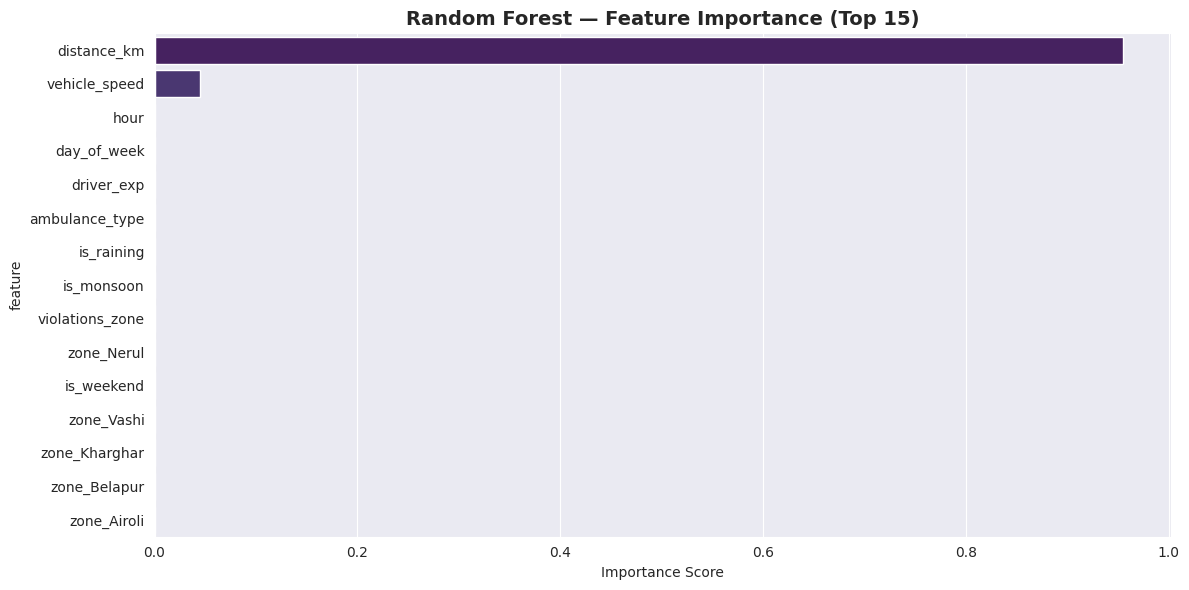

In [23]:
# STEP 6: Feature Importance
fi_df = pd.DataFrame({
    'feature'    : feature_cols,
    'importance' : rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print('📊 Top 10 Important Features:')
print(fi_df.head(10).to_string(index=False))

# Bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=fi_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Random Forest — Feature Importance (Top 15)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

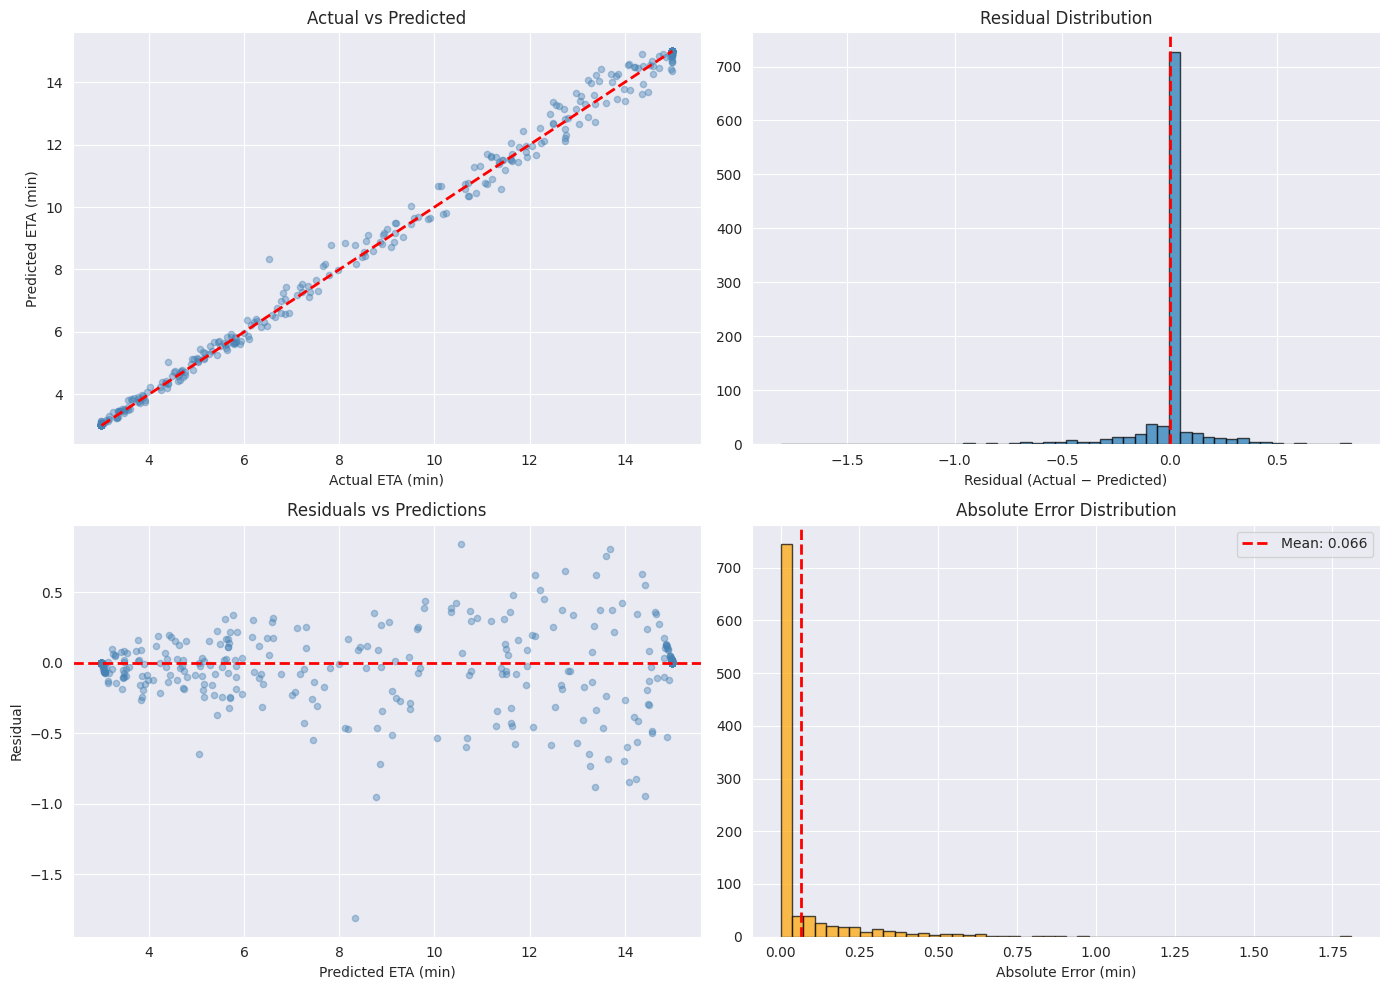


Error Summary:
  Mean error          : -0.0128 min
  Std of errors       : 0.1700 min
  Mean absolute error : 0.0662 min
  95th percentile     : 0.3901 min


In [24]:
# STEP 7: Error Analysis
residuals = y_test - pred_test
abs_errors = np.abs(residuals)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel 1: Actual vs Predicted
axes[0, 0].scatter(y_test, pred_test, alpha=0.4, s=20, color='steelblue')
axes[0, 0].plot([y_test.min(), y_test.max()],
                [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual ETA (min)')
axes[0, 0].set_ylabel('Predicted ETA (min)')
axes[0, 0].set_title('Actual vs Predicted')

# Panel 2: Residual Distribution
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].axvline(0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residual (Actual − Predicted)')
axes[0, 1].set_title('Residual Distribution')

# Panel 3: Residuals vs Predicted
axes[1, 0].scatter(pred_test, residuals, alpha=0.4, s=20, color='steelblue')
axes[1, 0].axhline(0, color='r', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted ETA (min)')
axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Residuals vs Predictions')

# Panel 4: Absolute Error Distribution
axes[1, 1].hist(abs_errors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].axvline(np.mean(abs_errors), color='r', linestyle='--', lw=2,
                   label=f'Mean: {np.mean(abs_errors):.3f}')
axes[1, 1].set_xlabel('Absolute Error (min)')
axes[1, 1].set_title('Absolute Error Distribution')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f'\nError Summary:')
print(f'  Mean error          : {np.mean(residuals):.4f} min')
print(f'  Std of errors       : {np.std(residuals):.4f} min')
print(f'  Mean absolute error : {np.mean(abs_errors):.4f} min')
print(f'  95th percentile     : {np.percentile(abs_errors, 95):.4f} min')

In [18]:
# Accuracy within tolerance thresholds
thresholds = [1, 2, 3, 5, 10]  # minutes

print('=' * 60)
print('🎯 ACCURACY WITHIN TOLERANCE (Test Set)')
print('=' * 60)

for t in thresholds:
    acc = np.mean(np.abs(y_test - pred_test) <= t) * 100
    print(f'  Within ±{t:2d} min : {acc:.2f}%')

print()

# Also show for Train and Val
for split_name, y_true, y_pred in [
    ('Test',  y_test,  pred_test)
]:
    within_2 = np.mean(np.abs(y_true - y_pred) <= 2) * 100
    within_5 = np.mean(np.abs(y_true - y_pred) <= 5) * 100
    print(f'{split_name:6s} → within ±2 min: {within_2:.2f}%  |  within ±5 min: {within_5:.2f}%')

🎯 ACCURACY WITHIN TOLERANCE (Test Set)
  Within ± 1 min : 99.90%
  Within ± 2 min : 100.00%
  Within ± 3 min : 100.00%
  Within ± 5 min : 100.00%
  Within ±10 min : 100.00%

Test   → within ±2 min: 100.00%  |  within ±5 min: 100.00%


In [19]:
# STEP 8: Save Model & Feature List to Drive
SAVE_PATH = f'{DATA_PATH}/models'
os.makedirs(SAVE_PATH, exist_ok=True)

joblib.dump(rf_model,    f'{SAVE_PATH}/rf_model.pkl')
joblib.dump(feature_cols, f'{SAVE_PATH}/rf_features.pkl')

print(f' Model saved   → {SAVE_PATH}/rf_model.pkl')
print(f' Features saved → {SAVE_PATH}/rf_features.pkl')

# Final summary
print('\n' + '='*60)
print(' TRAINING COMPLETE — SUMMARY')
print('='*60)
print(f'  Test MAE  : {test_metrics["MAE"]:.4f} min  ← your RF baseline')
print(f'  Top feature: {fi_df.iloc[0]["feature"]} (importance: {fi_df.iloc[0]["importance"]:.4f})')

 Model saved   → /content/drive/MyDrive/navi mumbai dataset/models/rf_model.pkl
 Features saved → /content/drive/MyDrive/navi mumbai dataset/models/rf_features.pkl

 TRAINING COMPLETE — SUMMARY
  Test MAE  : 0.0654 min  ← your RF baseline
  Top feature: distance_km (importance: 0.9538)


In [20]:
# Download RF model files to your local computer
from google.colab import files

files.download(f'{SAVE_PATH}/rf_model.pkl')
files.download(f'{SAVE_PATH}/rf_features.pkl')

print(' Check your browser Downloads folder!')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Check your browser Downloads folder!
